# Portfolio Benchmark

This notebook imports saved mean-variance portfolio runs from `results/portfolio`. It is analysis-only and does not run training.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd()
if not (ROOT / 'src').exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / 'src'))

from mfc.visualization import (
    best_runs_by_label,
    gradient_diagnostics,
    load_runs,
    objective_table,
    plot_state_flow,
    plot_validation_rewards,
    runtime_table,
    transport_correction_table,
)

ENV = 'portfolio'
RESULTS_ROOT = ROOT / 'results'
runs = load_runs(RESULTS_ROOT, env=ENV)
print(f'Loaded {len(runs)} saved runs from {RESULTS_ROOT / ENV}')

Loaded 30 saved runs from /home/adonis/Internship/mfc/results/portfolio


## Validation Reward

Mean validation reward over training, with one standard deviation across seeds. The terminal reward is expected wealth penalized by terminal variance.

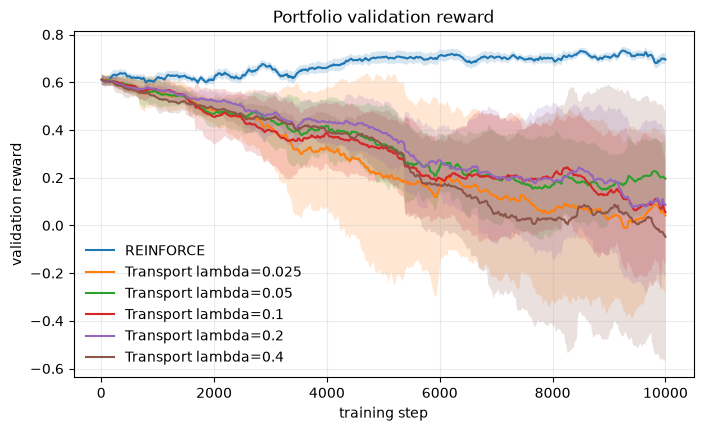

In [2]:
if not runs:
    print('No saved runs yet. Run scripts/run.py before executing the analysis cells.')
else:
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_validation_rewards(runs, env=ENV, horizon=10, flow='exact', ax=ax)
    ax.set_title('Portfolio validation reward')
    plt.show()

## Wealth Mean and Variance Flow

Population wealth mean and variance induced by the best saved policy for each algorithm and perturbation level.

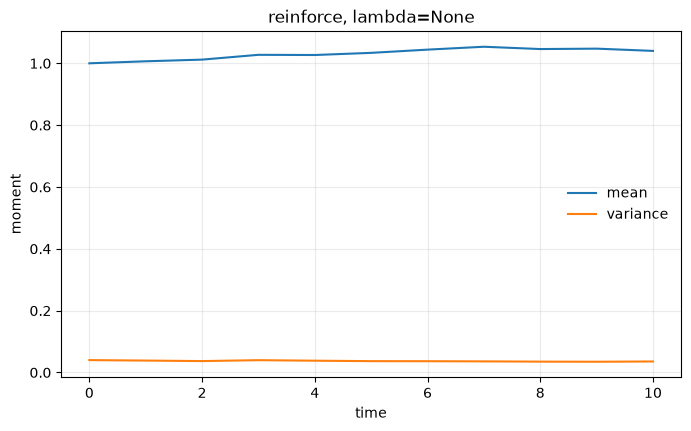

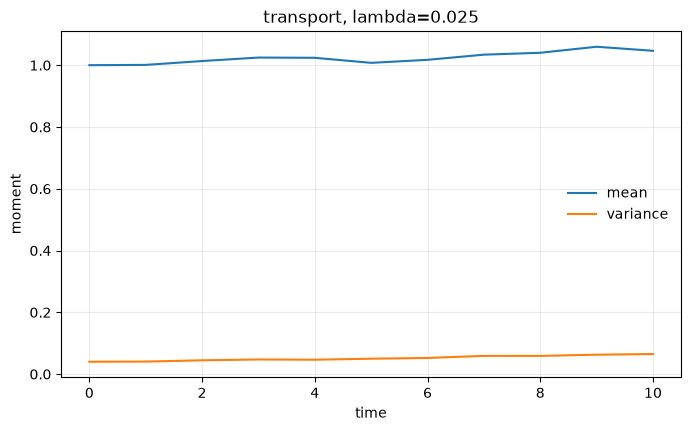

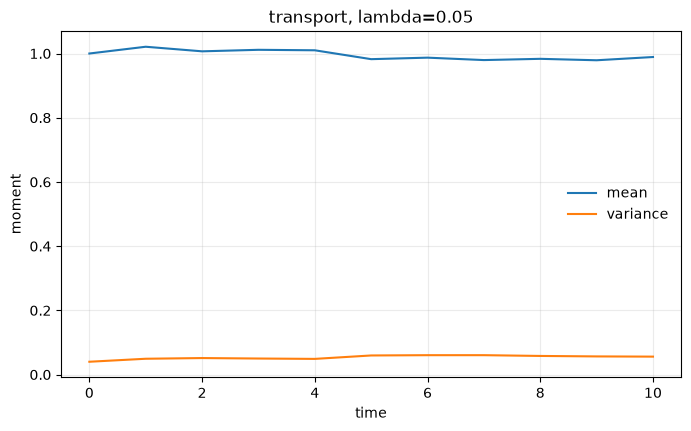

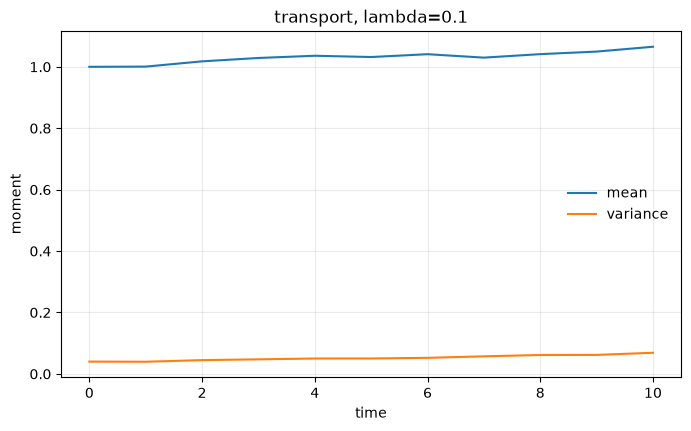

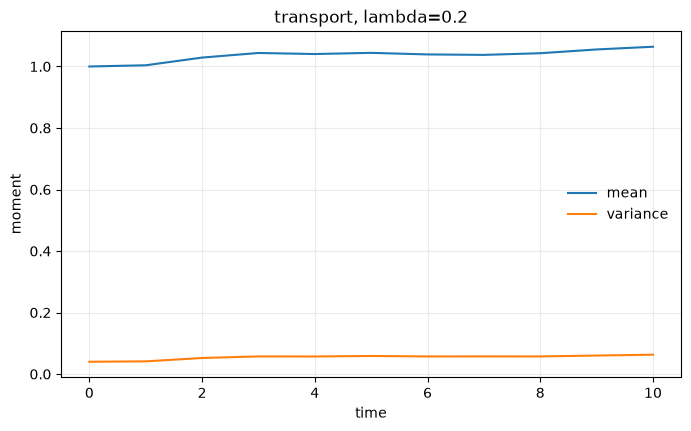

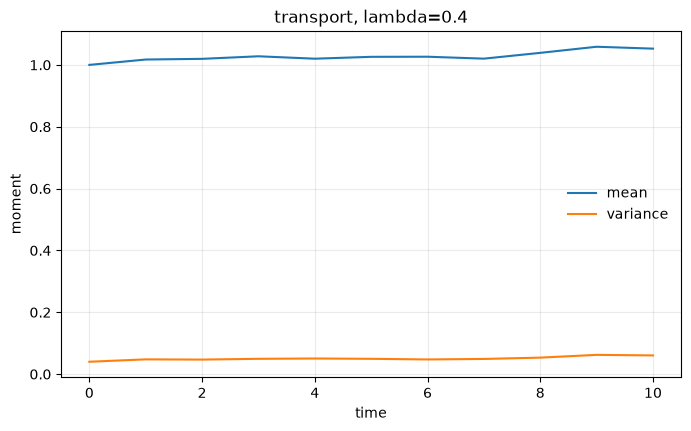

In [3]:
for run in best_runs_by_label(runs):
    fig, ax = plt.subplots(figsize=(8, 4.5))
    plot_state_flow(run, ax=ax)
    meta = run['metadata']
    ax.set_title(f"{meta['algorithm']}, lambda={meta['perturbation']}")
    plt.show()

## Objective Table: J vs J^lambda

Closed-form objective values at the learned policy, with the analytical unperturbed optimum included when available.

In [4]:
display(objective_table(runs))

,env,label,flow,horizon,seed,validation_reward,objective_convention,J0,J0_star,Jlambda,Jlambda_star
0,portfolio,REINFORCE,exact,10,0,0.689227,reward,0.684570,0.80247,NaN,NaN
1,portfolio,REINFORCE,exact,10,1,0.714119,reward,0.684307,0.80247,NaN,NaN
2,portfolio,REINFORCE,exact,10,2,0.709252,reward,0.684313,0.80247,NaN,NaN
3,portfolio,REINFORCE,exact,10,3,0.703176,reward,0.683606,0.80247,NaN,NaN
4,portfolio,REINFORCE,exact,10,4,0.659064,reward,0.683632,0.80247,NaN,NaN
5,portfolio,Transport lambda=0.025,exact,10,0,0.410996,reward,0.397594,0.80247,0.384154,0.783860
6,portfolio,Transport lambda=0.025,exact,10,1,-0.305662,reward,-0.247679,0.80247,-0.263080,0.783860
7,portfolio,Transport lambda=0.025,exact,10,2,0.341386,reward,0.269093,0.80247,0.256111,0.783860
8,portfolio,Transport lambda=0.025,exact,10,3,0.020168,reward,-0.023801,0.80247,-0.037144,0.783860
9,portfolio,Transport lambda=0.025,exact,10,4,-0.260853,reward,-0.345229,0.80247,-0.358056,0.783860


## Transport Gradient Diagnostics

Optional Monte Carlo check of bias, MSE, cosine similarity, and perturbation bias against the exact portfolio gradient oracle.

In [8]:
RUN_GRADIENT_DIAGNOSTICS = True
N_REPLICATIONS = 20

if RUN_GRADIENT_DIAGNOSTICS:
    tables = []
    for run in runs:
        try:
            tables.append(gradient_diagnostics(run, n_replications=N_REPLICATIONS))
        except ValueError:
            pass
    display(pd.concat(tables, ignore_index=True) if tables else pd.DataFrame())
else:
    print('Set RUN_GRADIENT_DIAGNOSTICS = True to recompute gradient bias/MSE diagnostics.')

,env,label,flow,horizon,lambda,n_parameters,diagnostic_n_particles,n_replications,bias_norm,estimate_std,...,bias_z,bias_z_null_rms,bias_chi2_stat,bias_chi2_df,bias_chi2_pvalue,mse,cosine_similarity,exact_gradient_norm,estimate_gradient_norm_mean,perturbation_bias_norm
0,portfolio,Transport lambda=0.025,exact,10,0.025,20,510,20,1.279787e+13,6.872253e+13,...,0.832824,1.0,13.871928,20,0.836930,2.325216e+26,-0.019225,0.236697,1.873749e+13,0.000905
1,portfolio,Transport lambda=0.025,exact,10,0.025,20,510,20,1.114193e+13,6.611970e+13,...,0.753606,1.0,11.358446,20,0.936392,2.138683e+26,-0.049621,0.482301,2.905380e+13,0.001212
2,portfolio,Transport lambda=0.025,exact,10,0.025,20,510,20,9.068472e+12,5.954712e+13,...,0.681065,1.0,9.276983,20,0.979471,1.725402e+26,-0.742777,0.315439,1.899059e+13,0.000895
3,portfolio,Transport lambda=0.025,exact,10,0.025,20,510,20,1.283992e+13,8.520293e+13,...,0.673942,1.0,9.083961,20,0.981914,3.530713e+26,0.096330,0.413835,3.070139e+13,0.001015
4,portfolio,Transport lambda=0.025,exact,10,0.025,20,510,20,4.538512e+12,5.537406e+13,...,0.366541,1.0,2.687040,20,0.999998,1.466785e+26,-0.285397,0.490831,2.753530e+13,0.000991
5,portfolio,Transport lambda=0.05,exact,10,0.050,20,510,20,1.106796e+10,6.870012e+10,...,0.720485,1.0,10.381972,20,0.960705,2.303110e+20,-0.186832,0.327962,2.091234e+10,0.003901
6,portfolio,Transport lambda=0.05,exact,10,0.050,20,510,20,6.712323e+09,9.783922e+10,...,0.306814,1.0,1.882694,20,1.000000,4.569472e+20,0.096052,0.374843,3.605000e+10,0.003757
7,portfolio,Transport lambda=0.05,exact,10,0.050,20,510,20,2.643075e+09,3.093528e+10,...,0.382094,1.0,2.919919,20,0.999997,4.580639e+19,0.605260,0.359191,1.096561e+10,0.003599
8,portfolio,Transport lambda=0.05,exact,10,0.050,20,510,20,5.439267e+09,4.352252e+10,...,0.558909,1.0,6.247590,20,0.998519,9.145426e+19,0.301190,0.240936,1.576142e+10,0.003664
9,portfolio,Transport lambda=0.05,exact,10,0.050,20,510,20,7.742501e+09,7.240434e+10,...,0.478224,1.0,4.573970,20,0.999862,2.520108e+20,-0.192591,0.405016,3.380806e+10,0.003643


## Missing Mean-Field Correction Term

Optional diagnostic comparing the full transport gradient with the policy-only term. The difference is the mean-field correction absent from classical REINFORCE.

In [9]:
RUN_CORRECTION_DIAGNOSTIC = True

if RUN_CORRECTION_DIAGNOSTIC:
    tables = []
    for run in runs:
        try:
            tables.append(transport_correction_table(run, n_replications=N_REPLICATIONS))
        except ValueError:
            pass
    display(pd.concat(tables, ignore_index=True) if tables else pd.DataFrame())
else:
    print('Set RUN_CORRECTION_DIAGNOSTIC = True to estimate the missing correction term.')

KeyboardInterrupt: 

## Runtime Table

Average elapsed time and estimated simulator budget for each algorithm configuration.

In [ ]:
display(runtime_table(runs))

,env,algorithm,perturbation,horizon,flow,setup_seconds_mean,setup_seconds_std,train_step_seconds_mean,train_step_seconds_std,validation_seconds_mean,validation_seconds_std,elapsed_seconds_mean,elapsed_seconds_std,seconds_per_step_mean,wall_seconds_per_step_mean,validation_seconds_per_call_mean,simulator_budget_mean,n_runs
0,portfolio,reinforce,NaN,10,exact,7.616775,0.389286,42.628618,0.250141,2.968728,0.016897,53.242122,0.474743,0.004263,0.005324,0.002969,5110.0,5
1,portfolio,transport,0.025,10,exact,7.519083,0.447747,289.209306,1.235578,2.571882,0.014086,299.330295,1.369395,0.028921,0.029933,0.002572,5110.0,5
2,portfolio,transport,0.050,10,exact,8.710221,1.685450,289.308062,0.907204,2.571591,0.009202,300.619034,1.939818,0.028931,0.030062,0.002572,5110.0,5
3,portfolio,transport,0.100,10,exact,8.640464,0.786590,292.641109,3.211852,2.612692,0.024478,303.924568,2.862974,0.029264,0.030392,0.002613,5110.0,5
4,portfolio,transport,0.200,10,exact,7.546879,0.164411,287.301164,0.860028,2.569570,0.014424,297.447434,0.905171,0.028730,0.029745,0.002570,5110.0,5
5,portfolio,transport,0.400,10,exact,8.765024,1.260250,284.135507,3.582740,2.540778,0.030388,295.469692,2.448077,0.028414,0.029547,0.002541,5110.0,5
